# Exploratory Data Analysis: Vehicle Fuel Efficiency

**Author:** Luke Stevers

## Research Question

What vehicle characteristics are associated with differences in fuel efficiency?

## Dataset

This project uses the Seaborn `mpg` dataset, which contains information about
automobiles including miles per gallon, cylinders, engine displacement,
horsepower, vehicle weight, acceleration, model year, origin, and vehicle name.

The goal is to explore the dataset, evaluate its data quality, examine
distributions, compare groups, and investigate relationships between variables.

### Data Source

The dataset is the `mpg` dataset provided through Seaborn's built-in example
datasets. It contains automobile measurements and characteristics used for
exploratory analysis and statistical practice.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("mpg")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## 1. Load the Data

The `mpg` dataset contains information about automobiles and their fuel
efficiency. Each row represents one vehicle.

The dataset includes fuel efficiency (`mpg`), cylinders, engine displacement,
horsepower, vehicle weight, acceleration, model year, origin, and vehicle name.

The goal of this analysis is to explore which vehicle characteristics are
associated with differences in fuel efficiency.

### Initial Observation

The dataset contains both numerical measurements and categorical information,
which makes it useful for exploring distributions, group comparisons, and
relationships between variables.

## 2. Inspect the Data

Before analyzing the data, I want to examine its size, column names, and data
types. This provides an initial understanding of the structure of the dataset.

In [16]:
print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (398, 9)

Column names:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']

Data types:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object


### Observation

The dataset contains 398 vehicles and 9 variables. Most of the variables are
numeric measurements describing vehicle performance and characteristics.
The `origin` and `name` columns provide categorical or descriptive
information.

The combination of numerical and categorical variables will allow me to
investigate both relationships between measurements and differences between
groups of vehicles

## 3. Check Data Quality

Before analyzing relationships in the data, I need to check for missing
values and duplicate rows. Missing values could affect calculations or
visualizations, so I want to identify them before continuing.

In [17]:
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [18]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Data Quality Observation

The dataset contains 6 missing values in the `horsepower` column, while all
other columns are complete. There are no duplicate rows.

Because horsepower is missing for 6 vehicles, analyses involving horsepower
will use fewer observations unless the missing values are handled. For this
exploratory analysis, I will keep the original data and account for missing
values when analyzing horsepower.

## 4. Describe the Numerical Variables

Descriptive statistics provide a quick summary of the numerical variables.
I will examine measures such as the mean, standard deviation, minimum,
maximum, and quartiles to understand the typical values and spread of the
vehicle measurements.

In [19]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


### Descriptive Statistics Observation

The dataset shows substantial variation among the vehicles. Fuel efficiency
ranges from 9.0 to 46.6 MPG, while vehicle weight ranges from 1,613 to
5,140 pounds. The average vehicle weighs about 2,970 pounds and has fuel
efficiency of about 23.15 MPG.

The wide range of vehicle weights and fuel-efficiency values makes these
variables useful for investigating whether vehicle weight is associated with
fuel efficiency.

## 5. Visualize Distributions

Visualizations can reveal patterns that are harder to see in numerical
summaries alone. I will begin by examining the distribution of fuel
efficiency and then look at the distribution of vehicle weight.

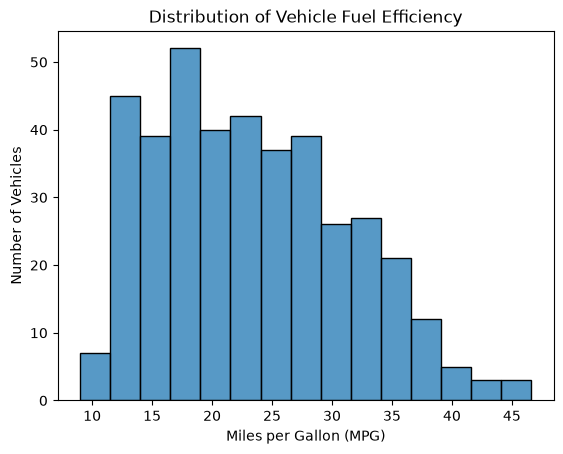

In [20]:
sns.histplot(data=df, x="mpg", bins=15)

plt.title("Distribution of Vehicle Fuel Efficiency")
plt.xlabel("Miles per Gallon (MPG)")
plt.ylabel("Number of Vehicles")

plt.show()

### Distribution Observation

The distribution of vehicle fuel efficiency is concentrated mostly between
about 12 and 30 MPG. Fewer vehicles have fuel efficiency above 35 MPG, and
the distribution has a longer tail toward the higher MPG values.

This suggests that the vehicles in the dataset are not evenly distributed
across the full range of fuel efficiency.

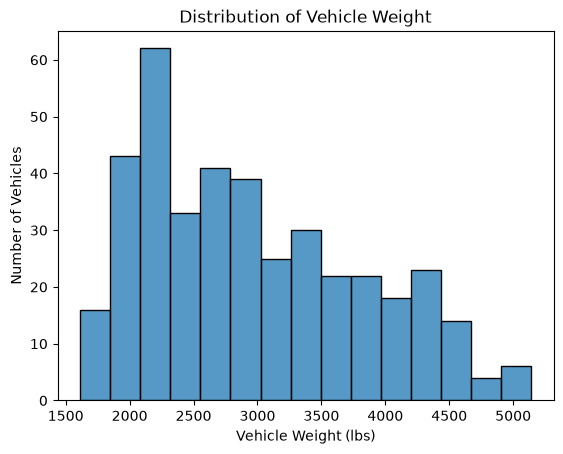

In [21]:
sns.histplot(data=df, x="weight", bins=15)

plt.title("Distribution of Vehicle Weight")
plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Number of Vehicles")

plt.show()

### Weight Distribution Observation

Vehicle weights are concentrated primarily between about 1,900 and 3,500
pounds. There are fewer vehicles at the heavier end of the distribution,
with some vehicles weighing more than 5,000 pounds.

The variation in vehicle weight provides an opportunity to investigate whether
heavier vehicles tend to have different fuel efficiency than lighter vehicles.

## 6. Explore Relationships

One goal of this analysis is to investigate whether vehicle characteristics
are associated with fuel efficiency. I will first examine the relationship
between vehicle weight and miles per gallon.

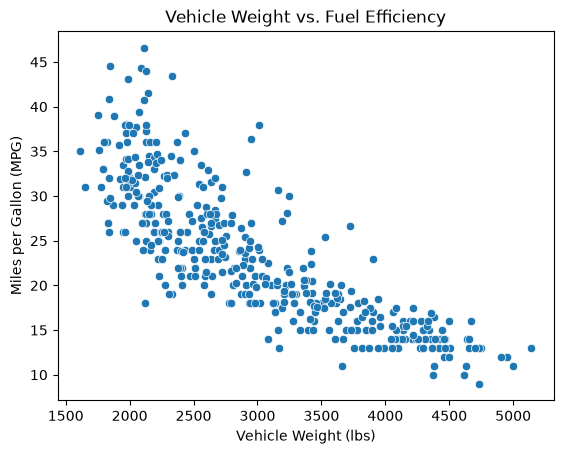

In [22]:
sns.scatterplot(data=df, x="weight", y="mpg")

plt.title("Vehicle Weight vs. Fuel Efficiency")
plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Miles per Gallon (MPG)")

plt.show()

### Weight and Fuel Efficiency Observation

The scatter plot shows a clear negative association between vehicle weight and
fuel efficiency. In general, lighter vehicles tend to have higher MPG values,
while heavier vehicles tend to have lower MPG values.

There is some variation around this overall pattern, suggesting that vehicle
weight is associated with fuel efficiency but is not the only characteristic
that may be related to MPG.

In [23]:
weight_mpg_correlation = df["weight"].corr(df["mpg"])

print(f"Correlation between vehicle weight and MPG: {weight_mpg_correlation:.3f}")

Correlation between vehicle weight and MPG: -0.832


### Correlation Observation

The correlation between vehicle weight and MPG is -0.832. This indicates a
strong negative linear association between the two variables. In this
dataset, heavier vehicles generally have lower fuel-efficiency values.

The correlation measures association rather than causation, so this result
does not by itself show that vehicle weight causes lower fuel efficiency.

## 7. Compare Fuel Efficiency by Number of Cylinders

Another question is whether fuel efficiency differs among vehicles with
different numbers of cylinders. A box plot allows me to compare the
distribution of MPG across the cylinder groups.

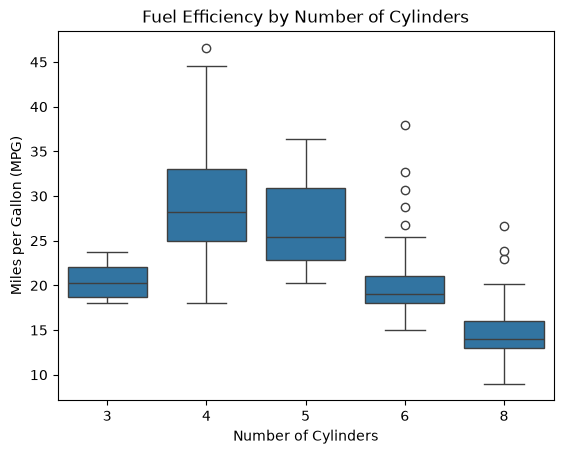

In [24]:
sns.boxplot(data=df, x="cylinders", y="mpg")

plt.title("Fuel Efficiency by Number of Cylinders")
plt.xlabel("Number of Cylinders")
plt.ylabel("Miles per Gallon (MPG)")

plt.show()

### Cylinder Group Observation

Fuel efficiency varies across the cylinder groups. Vehicles with 4 cylinders
generally have higher MPG values than vehicles with 6 or 8 cylinders, while
8-cylinder vehicles generally have the lowest MPG values.

There is variation within each group, including several higher-MPG observations
among the 6- and 8-cylinder vehicles. The 3-cylinder group contains relatively
few observations, so conclusions about that group should be made cautiously.

Overall, the box plot suggests that the number of cylinders is associated
with differences in fuel efficiency in this dataset.

## 8. Compare Fuel Efficiency by Vehicle Origin

The dataset also identifies the origin of each vehicle. I will compare MPG
across vehicles from the United States, Europe, and Japan to see whether
fuel-efficiency distributions differ among these groups.

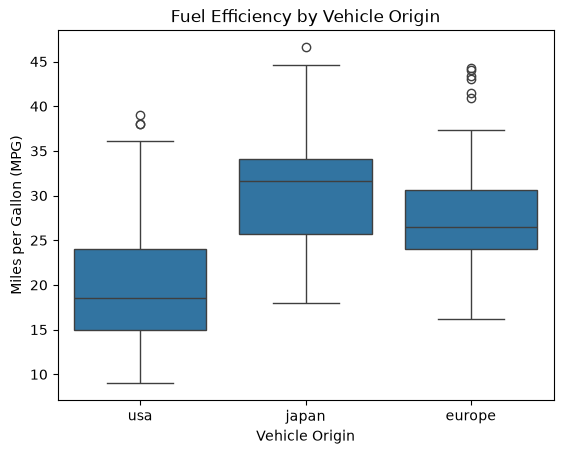

In [25]:
sns.boxplot(data=df, x="origin", y="mpg")

plt.title("Fuel Efficiency by Vehicle Origin")
plt.xlabel("Vehicle Origin")
plt.ylabel("Miles per Gallon (MPG)")

plt.show()

### Vehicle Origin Observation

Fuel-efficiency distributions differ across the three vehicle-origin groups.
Vehicles from Japan have the highest typical MPG in this dataset, followed by
vehicles from Europe. Vehicles from the USA have the lowest typical MPG
distribution.

There is still variation within each origin group, and the distributions
overlap. This suggests that vehicle origin is associated with differences in
fuel efficiency, but origin alone does not explain all of the variation in
MPG.

## 9. Summary and Interpretation

This exploratory analysis examined vehicle fuel efficiency using the Seaborn
`mpg` dataset. The analysis focused on the relationships between MPG and
vehicle weight, number of cylinders, and vehicle origin.

### Key Findings

- The dataset contains 398 vehicles and 9 variables.
- There are 6 missing values in the `horsepower` column and no duplicate rows.
- Vehicle fuel efficiency ranges from 9.0 to 46.6 MPG.
- Vehicle weight and MPG have a strong negative correlation of **-0.832**.
- The scatter plot shows that heavier vehicles generally have lower MPG.
- MPG distributions differ across cylinder groups, with 4-cylinder vehicles
  generally showing higher MPG than 6- and 8-cylinder vehicles.
- MPG distributions also differ by vehicle origin. Japanese vehicles have the
  highest typical MPG in this dataset, followed by European and then U.S.
  vehicles.

### Interesting Pattern

The strongest pattern in the analysis is the relationship between vehicle
weight and fuel efficiency. The correlation of -0.832 indicates a strong
negative linear association, which is also clearly visible in the scatter plot.

### Data Quality

The missing horsepower values are an important limitation. Analyses involving
horsepower would need to account for the 6 vehicles without recorded
horsepower values.

### Next Steps

If I continued this analysis, I would investigate whether the relationship
between vehicle weight and MPG changes across model years or vehicle origins.
I could also examine horsepower and displacement to determine how multiple
vehicle characteristics are related to fuel efficiency.